# Model of the LIDA cavity for the beam alignment

A simple geometric model to aid the learning process and analytic calculations.
 - 3x3 matrices for ray alignment vectors $$\begin{pmatrix}
x \\ \theta_x \\ 1
\end{pmatrix},~~~\begin{pmatrix}
y \\ \theta_y \\ 1
\end{pmatrix}
$$
 - standard ABCD matrices for the Gaussian beam parameter tracking $$
q' = \frac{Aq+B}{Cq+d}
$$
 - NOT following the sign conventions from Denis's script in elog [#639](https://lnx0.sr.bham.ac.uk:8081/Dark+Matter/639) (but providing `.denisify()` method to convert the matrices into Denis's convention):

![](./schematic.svg)
 - Astigmatic beams: $$u(x,y,z)=u_x(x,z)u_y(y,z),$$ $$u_{x,y} = 
 \frac{1}{\sqrt{q_{x,y}}}\exp\left(-i\frac{2\pi}{\lambda}\frac{\{x,y\}^2}{2q_{x,y}}\right),$$ $$
q_{x,y} = z_{x,y} + i z_{R_{x,y}},$$ $$
w_{x,y} = \frac{\lambda}{\pi}\frac{z_{x,y}^2+z_{R_{x,y}}^2}{z_{R_{x,y}}}$$ $$
I=|u|^2 = \frac{2P}{\pi w_x w_y}\exp\left(-\frac{2x^2}{w_x^2} - \frac{2y^2}{w_y^2}\right)$$

In [1]:
import numpy as np
from scipy import constants
import cv2 as cv
import matplotlib.pyplot as plt
# import random
import finesse

class MirrorImage():
    """
    This class enables functionality fircreating pitcures of the mirrors with OpenCV, mimicking the photographs taken by cameras.
    Most parameters are kept in MirrorImage().image_properties and can be directly changed in the objects if required.
    Images are created with `get_mirror_image()` method.
    This class is not supposed to be used as is but rather inherited by classes that represent cavities and/or mirrors.
    """
    default_image_properties = {
        'im_width_px' : 400,
        'im_height_px' : 400,
        'margins_px' : 10,
        'mirror_base_diameter' : 25.4e-3,
        'mirror_edge_thickness' : 0.006,
        'mirror_edge_colour' : 128,
        'mirror_edge_line_type' : cv.LINE_8,
        'camera_threshold_level': 1/np.e**2,
        'gaussian_max_colour' : 255,
        'dtype' : np.uint8
    }

    def scale(self, absolute=False):
        """Scaling coefficient to convert the absolute sizes of the beam and mirror parameters into pixels for image drawing.
        The returned value is either the absolute coefficeint (px/m) if absolute=True 
        or the relative coefficient (px) for conversion the fractions of the mirror diameter"""
        p = self.image_properties
        min_px = min(p['im_width_px'],p['im_height_px'])
        # This would need to be reworked if the mirror becomes elliptical
        scale_abs = (min_px - 2*p['margins_px']) / p['mirror_base_diameter'] #px/m
        scale_rel = scale_abs * p['mirror_base_diameter'] # px
        if absolute:
            return scale_abs
        else:
            return scale_rel
        
    def draw_mirror_edge(self, img):
        """Draws the border of the mirror."""
        p = self.image_properties
        scale_rel = self.scale()
        scale_abs = self.scale(absolute=True)

        # mirror centre
        centre_px = (p['im_width_px']//2, p['im_height_px']//2)
        axes_px = (int(p['mirror_base_diameter']*scale_abs//2), int(p['mirror_base_diameter']*scale_abs//2))
        
        return cv.ellipse(img,
                   centre_px, # ellipse centre
                   axes_px, # ellipse half-axes
                   0, # axis angle
                   0, # arc starting angle
                   360, # arc ending angle
                   p['mirror_edge_colour'], # colour
                   int(p['mirror_edge_thickness']*scale_rel), # thickness
                   p['mirror_edge_line_type'] # OpenCV line type
                  )
        
    def draw_beam_spot(self, img, xc, yc, wx, wy):
        """
        Draws the beam spot on image `img`.
        `xc` and `yc` are the coordinates of the beam spot centre with respect to the mirror centre.
        `wx` and `wy` are the beam radii along x and y.
        These parameters must be specified in real units of length (meters).
        """
        p = self.image_properties
        scale_rel = self.scale()
        scale_abs = self.scale(absolute=True)
        # mirror centre and axes
        mirror_centre_px = (p['im_width_px']//2, p['im_height_px']//2)
        mirror_axes_px = (int(p['mirror_base_diameter']*scale_abs//2), int(p['mirror_base_diameter']*scale_abs//2))
        # converting the parameters to pixels
        xc_px, yc_px, wx_px, wy_px = [param*scale_abs for param in [-xc, -yc, wx, wy]]
        # creating the coordinate grids
        X,Y = np.meshgrid(np.arange(p['im_width_px']), np.arange(p['im_height_px']))
        # calculating the gaussian blob
        A = p['gaussian_max_colour']/p['camera_threshold_level']
        beam_spot = A*np.exp(-2*(X-mirror_centre_px[0]-xc_px)**2/wx_px**2-2*(Y-mirror_centre_px[1]-yc_px)**2/wy_px**2)
        # adding the gaussian blob to the image taking care of the mirror location
        img = np.where((X-mirror_centre_px[0])**2/mirror_axes_px[0]**2+(Y-mirror_centre_px[1])**2/mirror_axes_px[1]**2<1, \
                       beam_spot+img[:,:], img[:,:])
        # capping the image to mimic the camera saturation
        img = np.where(img>255, 255, img)
        img = img.astype(p['dtype'])
        
        return img

    def get_mirror_img(self, xc, yc, wx, wy, label=None, **kwargs):
        """
        Returns a greyscale image of a mirror with a Gaussian beam spot on it.
        `xc` and `yc` are the coordinates of the beam spot centre with respect to the mirror centre.
        `wx` and `wy` are the beam radii along x and y.
        These parameters must be specified in real units of length (meters).
        """
        self.update_image_properties(**kwargs)
        p = self.image_properties
        imsize = (p['im_height_px'],p['im_width_px'])
        im = np.zeros(imsize, dtype=np.uint8)
        self.draw_mirror_edge(im)
        im=self.draw_beam_spot(im, xc, yc, wx, wy)
        if label is not None:
            cv.putText(im, label, (5,im.shape[0]-5), fontFace=cv.FONT_HERSHEY_DUPLEX, fontScale=1,color=255)
        return im
    def update_image_properties(self, **kwargs):
        self.image_properties.update(kwargs)
    def reset_image_properties(self):
        self.image_properties = self.default_image_properties.copy()
        

class MirrorAt45(MirrorImage):
    """
    A class describing a mirror in a rectangular cavity at near-45 deg angle of incidence in the yaw plane 
    and near-0 deg angle of incidence in the pitch plane.

    Radius of curvature sign follows the Finesse convention.
    """
    def __init__(self, pitch=0.0, yaw=0.0, radius_of_curvature=np.inf, unit='rad', cavity=None, label=None):
        if unit == 'rad':
            pass
        elif unit == 'deg':
            pitch, yaw = [np.deg2rad(x) for x in [pitch, yaw]]
        else:
            raise ValueError('Unknown unit')
        self.pitch      = pitch  # Rotation around horizontal axis 
        #                          (positive = CCW if looking from the side so that the beam reflects in the left half-plane)
        self.yaw        = yaw      # Rotation around vertical axis (positive = CCW if looking from the top)
        self.radius_of_curvature = radius_of_curvature  # Mirror curvature

        self.reset_image_properties()

        self.cavity = cavity
 
    def __str__(self):
        out = f"""
Mirror parameters:
RoC \t= {self.radius_of_curvature:.3e} m
pitch \t= {np.rad2deg(self.pitch):.3f} deg
yaw \t= {np.rad2deg(self.yaw):.3f} deg
        """
        return out

    def get_mirror_img(self, label=None, **kwargs):
        """
        Returns a greyscale image of a mirror with a Gaussian beam spot on it.
        The parameters must have been calculated previously and stored in the mirror.
        """
        return super().get_mirror_img(self.pos_x, self.pos_y, self.actual_wx, self.wy, label=label, **kwargs)

    def set_pitch(self, pitch, add=False, update_cavity_rays=True):
        if add:
            pitch += self.pitch
        self.pitch = pitch
        if update_cavity_rays and (self.cavity is not None):
            self.cavity.update_rays()
    def set_yaw(self, yaw, add=False, update_cavity_rays=True):
        if add:
            yaw += self.yaw
        self.yaw = yaw
        if update_cavity_rays and (self.cavity is not None):
            self.cavity.update_rays()

    def matrix_ray_reflection_x(self):
        return np.array([[-1, 0, 0], [2**1.5/self.radius_of_curvature, -1, 2*self.yaw], [0, 0, 1]])
    def matrix_ray_reflection_y(self):
        return np.array([[1, 0, 0], [-2/self.radius_of_curvature, 1, -2*self.pitch], [0, 0, 1]])
    def matrix_gauss_reflection_x(self):
        return np.array([[1, 0], [-2**1.5/(self.radius_of_curvature), 1]])
    def matrix_gauss_reflection_y(self):
        return np.array([[1, 0], [-2**0.5/(self.radius_of_curvature), 1]])

class RectangularCavity():
    """This class represents a rectangular cavity."""
    def __init__(self, mirror_spacings, radii_of_curvature, pitch=None, yaw=None, lambda0=1064e-9, unit='rad'):
        self.lambda0 = lambda0
        if pitch is None:
            pitch= [0.0]*4
        if yaw is None:
            yaw  = [0.0]*4
        # Adding mirrors
        self.mirrors=[]
        for cRoC, cPitch, cYaw in zip(radii_of_curvature, pitch, yaw):
            self.mirrors.append( MirrorAt45(radius_of_curvature=cRoC, pitch=cPitch, yaw=cYaw, cavity=self) )
        # Adding spaces, layout: S0->M0->S1->M1->S2 etc.
        self.mirror_spacings = mirror_spacings
        # updating matrices and solutions
        self.update_all()

    def set_all_pitches(self, pitch_arr, add=False, update_rays=True):
        for mirror, pitch in zip (self.mirrors, pitch_arr):
            mirror.set_pitch(pitch, add=add, update_cavity_rays=False)
        if update_rays:
            self.update_rays()
            
    def set_all_yaws(self, yaw_arr, add=False, update_rays=True):
        for mirror, yaw in zip (self.mirrors, yaw_arr):
            mirror.set_yaw(yaw, add=add, update_cavity_rays=False)
        if update_rays:
            self.update_rays()

    def set_all_yaws_and_pitches(self, yaw_arr, pitch_arr, add=False, update_rays=True):
        self.set_all_yaws(yaw_arr, add=add, update_rays=False)
        self.set_all_pitches(pitch_arr, add=add, update_rays=False)
        if update_rays:
            self.update_rays()
            
    def update_rays(self):
        """Updating ray matrices and eigenvectors"""
        # Ray matrices
        self.ray_matrix_x = self.compute_ray_matrix_x()
        self.ray_matrix_y = self.compute_ray_matrix_y()
        # Beam positions on the mirrors and propagation angles
        self.pos_x, self.theta_x, self.pos_y, self.theta_y = self.compute_ray_vectors()
        for i, mirror in enumerate(self.mirrors):
            mirror.pos_x = self.pos_x[i]
            mirror.theta_x = self.theta_x[i]
            mirror.pos_y = self.pos_y[i]
            mirror.theta_y = self.theta_y[i]

    def update_gauss(self):
        """Updating the ABCD matrices and cavity beam parameters"""
        self.gauss_matrix_x = self.compute_gauss_matrix_x()
        self.gauss_matrix_y = self.compute_gauss_matrix_y()
        # Gaussian beam parameters and actual beam radii on the mirrors
        self.q_x, self.q_y, self.wx, self.wy = self.compute_beam_parameters()
        for i, mirror in enumerate(self.mirrors):
            mirror.q_x = self.q_x[i]
            mirror.q_y = self.q_y[i]
            mirror.actual_wx = self.wx[i]
            mirror.wy = self.wy[i]

    def update_transfer_matrices(self):
        """Calculates direct and inverse matrices for transformations"""
        self.tm_yaw_to_pos_x, self.tm_yaw_to_theta_x, self.tm_pitch_to_pos_y, self.tm_pitch_to_theta_y = \
        self.compute_misalignment_matrices()
        self.tm_pos_x_to_yaw = np.linalg.inv(self.tm_yaw_to_pos_x)
        self.tm_theta_x_to_yaw = np.linalg.inv(self.tm_yaw_to_theta_x)
        self.tm_pos_y_to_pitch = np.linalg.inv(self.tm_pitch_to_pos_y)
        self.tm_theta_y_to_pitch = np.linalg.inv(self.tm_pitch_to_theta_y)

    def update_all(self):
        self.update_rays()
        self.update_gauss()
        self.update_transfer_matrices()
        
    def compute_misalignment_matrices(self):
        """Calculate transfer matrices from mirror misalignments to beam positions and propagation angles in x and y"""
        # Temporarily store the actual mirror misalignment angles
        original_yaw = [mirror.yaw for mirror in self.mirrors]
        original_pitch = [mirror.pitch for mirror in self.mirrors]

        test_angle = 1e-3
        tm_yaw_to_pos_x     = np.array([[],[],[],[]], dtype=float)
        tm_yaw_to_theta_x   = np.array([[],[],[],[]], dtype=float)
        tm_pitch_to_pos_y   = np.array([[],[],[],[]], dtype=float)
        tm_pitch_to_theta_y = np.array([[],[],[],[]], dtype=float)
        
        for mirror in self.mirrors:
            self.set_all_yaws_and_pitches([0.0]*4,[0.0]*4,update_rays=False)
            mirror.yaw = test_angle
            self.update_rays()
            
            tm_yaw_to_pos_x = np.hstack((tm_yaw_to_pos_x,(self.pos_x/test_angle).reshape((4,1))))
            tm_yaw_to_theta_x = np.hstack((tm_yaw_to_theta_x,(self.theta_x/test_angle).reshape((4,1))))

            mirror.yaw=0
            mirror.pitch=test_angle
            self.update_rays()
            
            tm_pitch_to_pos_y = np.hstack((tm_pitch_to_pos_y,(self.pos_y/test_angle).reshape((4,1))))
            tm_pitch_to_theta_y = np.hstack((tm_pitch_to_theta_y,(self.theta_y/test_angle).reshape((4,1))))

        # Restoring the original pitch and yaw
        self.set_all_yaws_and_pitches(original_yaw, original_pitch)
        
        return tm_yaw_to_pos_x, tm_yaw_to_theta_x, tm_pitch_to_pos_y, tm_pitch_to_theta_y

    def compute_ray_vectors(self):
        eigval_x, eigvect_x = np.linalg.eig(self.ray_matrix_x)
        vect_cur_x = eigvect_x[:,2]/eigvect_x[:,2][2]
        eigval_y, eigvect_y = np.linalg.eig(self.ray_matrix_y)
        vect_cur_y = eigvect_y[:,2]/eigvect_y[:,2][2]

        eps=1e-12
        if np.any(np.abs(vect_cur_x.imag)>eps*np.abs(vect_cur_x.real)):
            raise ValueError("Cavity seems stable but the calculated tangential ray vector is complex. Something's wrong!")
        if np.any(np.abs(vect_cur_y.imag)>eps*np.abs(vect_cur_y.real)):
            raise ValueError("Cavity seems stable but the calculated sagittal ray vector is complex. Something's wrong!")
        vect_cur_x = vect_cur_x.real
        vect_cur_y = vect_cur_y.real
        vect_0_x = vect_cur_x
        vect_0_y = vect_cur_y
        
        pos_x = []
        theta_x = []
        pos_y = []
        theta_y = []
        for L, mirror in zip(self.mirror_spacings, self.mirrors):
            
            propagation = self.matrix_ray_freespace(L)
            reflection_x  = mirror.matrix_ray_reflection_x()
            reflection_y  = mirror.matrix_ray_reflection_y()
            M_x = reflection_x @ propagation
            M_y = reflection_y @ propagation
            
            vect_cur_x = M_x @ vect_cur_x
            vect_cur_y = M_y @ vect_cur_y

            pos_x.append(vect_cur_x[0])
            theta_x.append(vect_cur_x[1])
            pos_y.append(vect_cur_y[0])
            theta_y.append(vect_cur_y[1])
            
        if (np.abs(vect_0_x[0])>eps and np.abs((vect_cur_x[0]-vect_0_x[0])/vect_0_x[0]) > eps) or \
        (np.abs(vect_0_x[0])<eps and np.abs(vect_cur_x[0])>eps):
            print(f"Warning! Ray x-position mismatch: {vect_cur_x[0]} vs {vect_0_x[0]}.")
        if (np.abs(vect_0_x[1])>eps and np.abs((vect_cur_x[1]-vect_0_x[1])/vect_0_x[1]) > eps) or \
        (np.abs(vect_0_x[1])<eps and np.abs(vect_cur_x[1])>eps):
            print(f"Warning! Ray x-angle mismatch: {vect_cur_x[1]} vs {vect_0_x[1]}.")
            
        if (np.abs(vect_0_y[0])>eps and np.abs((vect_cur_y[0]-vect_0_y[0])/vect_0_y[0]) > eps) or \
        (np.abs(vect_0_y[0])<eps and np.abs(vect_cur_y[0])>eps):
            print(f"Warning! Ray y-position mismatch: {vect_cur_y[0]} vs {vect_0_y[0]}.")
        if (np.abs(vect_0_y[1])>eps and np.abs((vect_cur_y[1]-vect_0_y[1])/vect_0_y[1]) > eps) or \
        (np.abs(vect_0_y[1])<eps and np.abs(vect_cur_y[1])>eps):
            print(f"Warning! Ray y-angle mismatch: {vect_cur_y[1]} vs {vect_0_y[1]}.")

        pos_x = np.array(pos_x)
        theta_x = np.array(theta_x)
        pos_y = np.array(pos_y)
        theta_y = np.array(theta_y)
            
        return pos_x, theta_x, pos_y, theta_y


    def compute_beam_parameters(self):
        """
        Actual beam sizes on all mirrors. Returns a tuple of four numpy arrays (for x and y direction).
        Note that the x-axis dimensions are the actual beam sizes on the mirrors, not their projections on the optical axes.
        """
        q_x_cur, q_y_cur = (self.compute_gauss_eigenmode_x(), self.compute_gauss_eigenmode_y())
        q_x_0, q_y_0 = (q_x_cur, q_y_cur)
        w_x, w_y = ([],[])
        q_x, q_y = ([],[])

        for L, mirror in zip(self.mirror_spacings, self.mirrors):
            
            propagation = self.matrix_gauss_freespace(L)
            reflection_x  = mirror.matrix_gauss_reflection_x()
            reflection_y  = mirror.matrix_gauss_reflection_y()
            M_x = reflection_x @ propagation
            M_y = reflection_y @ propagation
            
            Ax, Bx, Cx, Dx = M_x.flatten()
            Ay, By, Cy, Dy = M_y.flatten()
            q_x_cur = (Ax*q_x_cur+Bx)/(Cx*q_x_cur+Dx)
            q_y_cur = (Ay*q_y_cur+By)/(Cy*q_y_cur+Dy)

            q_x.append(q_x_cur)
            q_y.append(q_y_cur)
            w_x.append(self.q2w(q_x_cur)*2**0.5) #because of the 45 deg AOI
            w_y.append(self.q2w(q_y_cur))

        eps=1e-12
        if np.abs((q_x_cur-q_x_0)/q_x_0) > eps:
            print(f"Warning! Gauss beam along x-axis mismatch: {q_x_cur} vs {q_x_0}.")
        if np.abs((q_y_cur-q_y_0)/q_y_0) > eps:
            print(f"Warning! Gauss beam along y-axis mismatch: {q_y_cur} vs {q_y_0}.")
            
        
        q_x = np.array(q_x)
        q_y = np.array(q_y)
        w_x = np.array(w_x)
        w_y = np.array(w_y)
        return q_x, q_y, w_x, w_y
        

    def q2w(self, q=None):
        if q is None:
            q = np.array([self.q_x, self.q_y])
        w = np.sqrt(np.abs(self.lambda0 * np.abs(q)**2 / np.pi / np.imag(q)))
        return w
        

    def compute_gauss_eigenmode_x(self):
        if not self.is_stable():
            return None
        A, B, C, D = [complex(element) for element in self.gauss_matrix_x.flatten()]
        d = (D-A)**2 + 4*B*C
        q = (A-D + np.sqrt(d)) / (2*C)
        q = q.real + 1j*np.abs(q.imag)
        return q
    def compute_gauss_eigenmode_y(self):
        if not self.is_stable():
            return None
        A, B, C, D = [complex(element) for element in self.gauss_matrix_y.flatten()]
        d = (D-A)**2 + 4*B*C
        q = (A-D + np.sqrt(d)) / (2*C)
        q = q.real + 1j*np.abs(q.imag)
        return q
    def compute_gauss_eigenmode(self):
        return (self.compute_gauss_eigenmode_x(),self.compute_gauss_eigenmode_y())

        
    def compute_ray_matrix_x(self):
        """Computes the round-trip matrix for the beam in the tangential plane."""
        M = np.eye(3)
        for L, mirror in zip(self.mirror_spacings, self.mirrors):
            propagation = self.matrix_ray_freespace(L)
            reflection  = mirror.matrix_ray_reflection_x()
            M = reflection @ propagation @ M
        return M
    def compute_ray_matrix_y(self):
        """Computes the round-trip matrix for the beam in the sagittal plane."""
        M = np.eye(3)
        for L, mirror in zip(self.mirror_spacings, self.mirrors):
            propagation = self.matrix_ray_freespace(L)
            reflection  = mirror.matrix_ray_reflection_y()
            M = reflection @ propagation @ M
        return M
    def compute_gauss_matrix_x(self):
        """Computes the round-trip ABCD matrix for the beam in the tangential plane."""
        M = np.eye(2)
        for L, mirror in zip(self.mirror_spacings, self.mirrors):
            propagation = self.matrix_gauss_freespace(L)
            reflection  = mirror.matrix_gauss_reflection_x()
            M = reflection @ propagation @ M
        return M
    def compute_gauss_matrix_y(self):
        """Computes the round-trip ABCD matrix for the beam in the tangential plane."""
        M = np.eye(2)
        for L, mirror in zip(self.mirror_spacings, self.mirrors):
            propagation = self.matrix_gauss_freespace(L)
            reflection  = mirror.matrix_gauss_reflection_y()
            M = reflection @ propagation @ M
        return M

    def get_g_x(self):
        "Returns the geometric stability g-factor for the tangential plane"
        A, B, C, D = self.gauss_matrix_x.flatten()
        return (A+D+2)/4
    def get_g_y(self):
        "Returns the geometric stability g-factor for the sagittal plane"
        A, B, C, D = self.gauss_matrix_y.flatten()
        return (A+D+2)/4

    def is_stable(self, verbose=False):
        g_x = self.get_g_x()
        g_y = self.get_g_y()

        is_stable = g_x>0 and g_x<1 and g_y>0 and g_y<1

        if verbose:
            print(f"g_x = {g_x:.3f}\ng_y = {g_y:.3f}")
            if is_stable:
                print("Cavity is stable")
            else:
                print("Cavity is unstable")

        return is_stable

    def HOM_separation(self, unit='rad'):
        "Guoy phase separation between the higher-order modes"
        is_stable = self.is_stable()
        if is_stable:
            Ax, Bx, Cx, Dx = [complex(element) for element in self.gauss_matrix_x.flatten()]
            guoy_phase_x = 2*np.arccos(np.sign(Bx)*np.sqrt((Ax+Dx+2)/4))

            Ay, By, Cy, Dy = [complex(element) for element in self.gauss_matrix_y.flatten()]
            guoy_phase_y = 2*np.arccos(np.sign(By)*np.sqrt((Ay+Dy+2)/4))

            HOM_sep = 0.5 * (guoy_phase_x+guoy_phase_y)
        else:
            HOM_sep = 0

        if np.abs(HOM_sep.imag/HOM_sep.real)>1e-12:
            raise ValueError("Cavity seems stable but the calculated HOM separation is complex. Something's wrong!")

        HOM_sep = HOM_sep.real
        if unit   == 'rad':
            pass
        elif unit == 'deg':
            HOM_sep = np.rad2deg(HOM_sep)
        else:
            raise ValueError('Unknown unit')
            
        return HOM_sep

    @staticmethod
    def matrix_ray_freespace(L):
        return np.array([[1, L, 0], [0, 1, 0], [0, 0, 1]])
    @staticmethod
    def matrix_gauss_freespace(L):
        return np.array([[1, L], [0, 1]])
        
    @staticmethod
    def denisify(M):
        """
        Rearrange a transfer matrix to fit Denis's convention M1=IC,M2=OC,M3=CRVM,M4=IHR.
        Currently only the order of the elements is accounted for, not the minus signs.
        """
        return np.flip(M.transpose()).transpose()

    def get_mirror_images(self, labels=None, **kwargs):
        """Returns 4 arrays with images of all mirrors"""
        if labels == None:
            labels = [None]*4

        return [mirror.get_mirror_img(label=label, **kwargs) for mirror,label in zip(self.mirrors, labels)]
        
    def get_image_grid(self, layout="row", labels=None, **kwargs):
        """Returns a single combined array of 4 mirror images"""
        im0,im1,im2,im3 = self.get_mirror_images(labels, **kwargs)

        if layout == "row":
            combined_image = np.concatenate((im0,im1,im2,im3),axis=1)
        elif layout == "column":
            combined_image = np.concatenate((im0,im1,im2,im3),axis=0)
        elif layout == "grid":
            cim0 = np.concatenate((im2,im1), axis=1)
            cim1 = np.concatenate((im3,im0), axis=1)
            combined_image = np.concatenate((cim0,cim1), axis=0)

        else:
            raise ValueError

        return combined_image
    def show_image(self, unit_size=3, layout="row", labels=None, **kwargs):
        """Plots a combined array of mirror images"""

        img = self.get_image_grid(layout, labels, **kwargs)
        
        if layout == "row":
            figsize = (4*unit_size, 1*unit_size)
        elif layout == "column":
            figsize = (1*unit_size, 4*unit_size)
        elif layout == "grid":
            figsize = (2*unit_size, 2*unit_size)

        else:
            raise ValueError

        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        ax.axes.xaxis.set_ticks([])
        ax.axes.yaxis.set_ticks([])
        plt.show()
        
        return fig, ax

    
    def update_image_properties(self, **kwargs):
        for mirror in self.mirrors:
            mirror.update_image_properties(**kwargs)
    def reset_image_properties(self):
        for mirror in self.mirrors:
            mirror.reset_image_properties()
        

# Usage example
#### Layout:
![](./schematic.svg)
#### Mirror order:
IHR (HR mirror at the input side) -> OHR (curved HR mirror at the output side) -> OC (Output coupler) -> IC (input coupler)
#### Sign conventions, yaw:
 - all mirror misalignment angles and ray direction angles are positive if CCW (looking at the cavity from above)
 - all X axes are chosen such that a beam's displacement is positive when it steers towards the inside of the cavity (e.g. towards the left of its primary propagation direction if looking from above).
#### Sign conventions, pitch:
 - all ray direction angles are positive if CCW (looking from the side such that the beam propagates from the left to the right)
 - all Y axes are chosen such that a beam's displacement is positive when it steers upwards.

Original images of the mirrors:


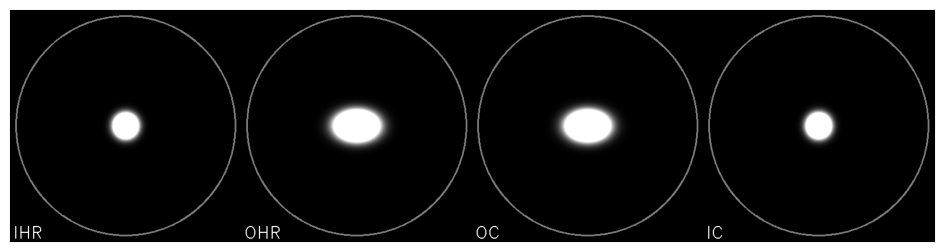

Transfer matrix, mirrors' yaw -> beam x-position at the mirrors (in m/rad):
[[ 2.2145 -7.2125  7.1145 -2.3125]
 [-7.2125  7.2125 -7.2125  7.2125]
 [ 7.1145 -7.2125  7.0145 -7.1125]
 [-2.3125  7.2125 -7.1125  2.2125]]

Target X-positions: [[-0.005], [0.007], [0.004], [-0.006]]
Target Y-positions: [[0.004], [-0.006], [-0.004], [0.003]]

New mirror misalignment angles:
    Yaw: [ 0.05479592 -0.05423354 -0.05479592  0.05520408]
    Pitch: [ 0.00602041 -0.01043217  0.00928571 -0.00428571]

Updated images of the mirrors:


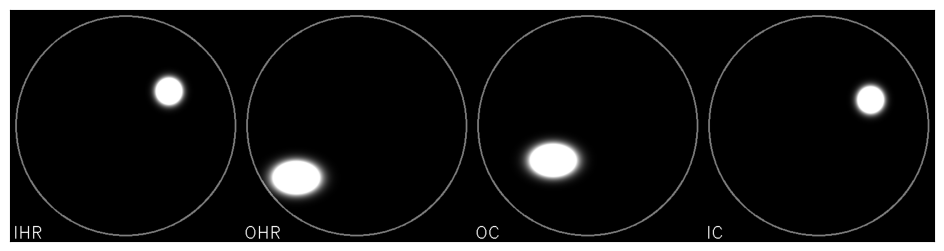

In [2]:
mirror_spacings = [0.1, 4.9, 0.1, 4.9]  # Distances between mirrors
radii_of_curvature = [np.inf, 10.2, np.inf, np.inf]  # Mirrors RoCs
mirror_labels = ['IHR', 'OHR', 'OC', 'IC'] # Mirror labels

# initialise the cavity and calculate the transfer matrices
cavity = RectangularCavity(mirror_spacings, radii_of_curvature)

# visualise the beam spots
print('Original images of the mirrors:')
cavity.show_image(labels=mirror_labels)

# print the transfer matrix from mirror misalignments in yaw to the beam positions at the mirrors
print('Transfer matrix, mirrors\' yaw -> beam x-position at the mirrors (in m/rad):')
print(np.array2string(cavity.tm_yaw_to_pos_x,precision=4,suppress_small=True))
# print('Transfer matrix, mirrors\' pitch -> beam y-position at the mirrors (in m/rad):')
# print(np.array2string(cavity.tm_pitch_to_pos_y,precision=4,suppress_small=True))

# set the target beam positions at the mirrors
target_pos_x = [[-5.0e-3], [7.0e-3], [4.0e-3], [-6.0e-3]]
target_pos_y = [[4.0e-3], [-6.0e-3], [-4.0e-3], [3.0e-3]]
print()
print(f"Target X-positions: {target_pos_x}")
print(f"Target Y-positions: {target_pos_y}")

# obtain corresponding mirror misalignment angles
yaw = (cavity.tm_pos_x_to_yaw @ target_pos_x).flatten()
pitch = (cavity.tm_pos_y_to_pitch @ target_pos_y).flatten()
# set the misalignment angles on mirrors
cavity.set_all_yaws_and_pitches(yaw, pitch)

print()
print("New mirror misalignment angles:")
print(f"    Yaw: {yaw}")
print(f"    Pitch: {pitch}")

# visualise the updated beam spots
print()
print("Updated images of the mirrors:")
_ = cavity.show_image(labels=mirror_labels)

In [3]:
type(np.random.default_rng())

numpy.random._generator.Generator

In [4]:
class CavityAlignment():
    DEFAULT_SCAN_RANGE_IN_FSRS = 2.1 # scan range expressed in the units of one FSR
    DEFAULT_MAXTEM = 5 # maximum order of TEM modes to model. 
    def __init__(self,
                 finesse_model,
                 cavity,
                 steering_mirror_1, steering_mirror_2,
                 scan_readout,
                 scan_actuator,
                 numpy_rng : np.random._generator.Generator = None
                ):
        """
        Parameters
        ----------
        finesse_model : finesse.model.Model
            Finesse model of the system, must at least include the cavity, two steering mirrors, and one readout.
        cavity : finesse.components.cavity.Cavity
            The cavity to be aligned (must be part of `finesse_model`)
        steering_mirror_1, steering_mirror_2 : finesse.components.beamsplitter.Beamsplitter
            Steering mirrors to align and translate the beam
        scan_readout : finesse.detectors.powerdetector.PowerDetector
            Finesse detector used to produce the cavity scans
        scan_actuator : finesse.components.laser.Laser or finesse.components.beamsplitter.Beamsplitter or finesse.components.mirror.Mirror
            Finesse component (Laser or mirror-like) that is being actuated on to produce cavity scans.
        numpy_rng : numpy.random._generator.Generator
            Numpy random number generator to use. If `None` (default), a new one will be initialised.
        """
        self.m   = finesse_model
        self.cav = cavity
        self.sm1 = steering_mirror_1
        self.sm2 = steering_mirror_2
        self.r   = scan_readout
        self.act = scan_actuator
        self.steering_motors = {}

        if self.m.Nhoms == 1:
            """If the current maxtem is zero, we should switch to the default value"""
            self.set_maxtem()

        if numpy_rng is None:
            self.numpy_rng = np.random.default_rng()
        else:
            self.numpy_rng = numpy_rng
        
        self.settings = {
            'noise_mean' : 5.0e-2,
            'noise_std' : 2.0e-2
        }
        self.misalignment_axes = {}

    @classmethod
    def two_mirror_cavity(cls,
                          Lcav = 1.0,
                          Rc = (np.inf, 3.0),
                          Refl = (0.98, 0.98),
                          Loss = (0.0, 0.0),
                          StSp = (1.0, 2.0),
                          maxtem = None,
                          numpy_rng = None
                         ):
        """
        Alternative constructor which automatically creates a simple predefined Finesse model of a 2-mirror optical cavity
        with a laser and two steering mirrors (SM1 and SM2) at given distances before the cavity, each at 45 deg angle of incidence.
        
        Parameters
        ----------
        Lcav : float
            Cavity length in metres.
        Rc : tuple of float
            2-tuple of the radii of curvature (RoCs) of the input coupler (IC) and the output coupler (OC) of the cavity.
            Default is (np.inf, 3.0).
        Refl : tuple of float
            2-tuple of reflection coefficients of IC and OC. Default is (0.98, 0.98).
        Loss : tuple of float
            2-tuple of loss coefficients of IC and OC. Default is (0.0, 0.0).
        StSp : tuple of float
            2-tuple containing the distance between steering mirror 1 (SM1) and SM2 as the zeroth element
            and the distance between SM2 and IC as the last element.
            Default is (1.0, 2.0).
        maxtem : int
            Maximum order of TEM modes to include in the simulation. If `None`, DEFAULT_MAXTEM will be used.
            Default is None.
        numpy_rng : numpy.random._generator.Generator
            Numpy random number generator to use. If `None` (default), a new one will be initialised.
        """
        
        model = finesse.Model()
        model_script = f"""
        l LASER
        s sLASER LASER.p1 SM1.p1
        bs SM1 R=1 T=0 alpha=45
        s s1 SM1.p2 SM2.p1 L={StSp[0]}
        bs SM2 R=1 T=0 alpha=45
        s s2 SM2.p2 IC.p1 L={StSp[1]}
        m IC R={Refl[0]} L={Loss[0]} Rc={Rc[0]}
        s sCAV IC.p2 OC.p1 L={Lcav}
        m OC R={Refl[1]} L={Loss[1]} Rc={Rc[1]}
        pd TRAN OC.p2.o
        pd REFL IC.p1.o
        
        cav CAV IC.p2
        """
        
        model.parse(model_script)
        if maxtem is not None:
            model.modes(maxtem=maxtem)
        
        return cls(model, model.CAV, model.SM1, model.SM2, model.TRAN, model.LASER, numpy_rng=numpy_rng)

    def add_misalignment_axes(self,
                              parameter_list : list[finesse.parameter.Parameter | str],
                              min_value_list : list[float],
                              max_value_list : list[float]
                             ) -> None:
        """
        Define axes (usually xbeta and ybeta of cavity mirrors) that are used to provide
        a random misalignment of the cavity in simulations.
        """
        for axis,min_value,max_value in zip(parameter_list, min_value_list, max_value_list):
            self.add_misalignment_axis(axis, min_value, max_value)
    def add_misalignment_axis(self,
                              axis : finesse.parameter.Parameter | str,
                              min_value : float,
                              max_value : float
                             ) -> None:
        """
        Defines one axis (usually xbeta or ybeta of one of the cavity mirrors) that is used to provide
        a random misalignment of the cavity in simulations.
        """

        misalignment_axis_dict = {}
        if isinstance(axis, finesse.parameter.Parameter):
            axis_obj = axis
            axis_name = axis.full_name
        elif isinstance(axis, str):
            axis_name = axis
            axis_obj = self.get_parameter_by_full_name(axis)
        else:
            raise TypeError(f"`axis` must be a string or a Finesse parameter, not {type(axis)}.")

        self.misalignment_axes[axis_name] = (axis_obj, min_value, max_value)
    
    def misalign_axes(self,
                      *args : finesse.parameter.Parameter | str
                     ) -> None:
        """
        Misalign axes of cavity components. The components need to be registered 
        by `add_misalignment_axes()` or `add_misalignment_axis()` first.
        If no arguments are given, all registered misalignment axes will be randomly misaligned.
        If arguments are given, only axes corresponding to the arguments will be misaligned.
        
        Parameters
        ----------
        *args : finesse.parameter.Parameter | str
            Axes to be misaligned. Each entry can be either the corresponding Finesse parameter or its full name.
            Parameters must be already registered in self.misalignment_axes.
        """
        if len(args) == 0:
            args = [k for k in self.misalignment_axes.keys()]
        for axis in args:
            if isinstance(axis, str):
                axis_key = axis
            elif isinstance(axis, finesse.parameter.Parameter):
                axis_key = axis.full_name
            else:
                raise TypeError(f"`axis` must be a string or a Finesse parameter, not {type(axis)}.")

            axis_obj, min_value, max_value = self.misalignment_axes[axis_key]
            axis_obj.value = self.numpy_rng.uniform(low = min_value, high=max_value)

    def set_maxtem(self, maxtem=None):
        """Sets the maximum order of the modes to model in the cavity to maxtem.
        If maxtem is not specified then the default value from CavityAlignment.DEFAULT_MAXTEM is returned."""
        if maxtem is None:
            maxtem = self.DEFAULT_MAXTEM
        
        self.m.modes(maxtem=maxtem)

    def cavity_scan(self,
                    scan_range_in_fsrs=None,
                    npoints=None, ppbw_resolution=None, ppfsr_resolution=None,
                    noisy=False,
                    plot=False, 
                    **kwargs
                   ):
        """Returns data of a cavity scan"""
        if scan_range_in_fsrs is None:
            scan_range_in_fsrs = self.DEFAULT_SCAN_RANGE_IN_FSRS
        scan_range = scan_range_in_fsrs * self.cav.FSR

        mask = np.array([npoints is not None, ppbw_resolution is not None, ppfsr_resolution is not None])
        if mask.sum() != 1:
            raise TypeError("Exactly one of the parameters `npoints`, `ppbw_resolution`, ppfsr_resolution` must be specified")

        if ppbw_resolution is not None:
            npoints = int(ppbw_resolution * self.cav.finesse * scan_range_in_fsrs)
        elif ppfsr_resolution is not None:
            npoints = int(ppfsr_resolution * scan_range_in_fsrs)

        if isinstance(self.act, finesse.components.laser.Laser):
            # Actuating on the laser frequency
            freq_start = 0 # do we ever need it to be non-zero?
            freq_stop  = freq_start + scan_range
            freqs = np.linspace(freq_start, freq_stop, npoints, endpoint=False)
            action = finesse.analysis.actions.Sweep(
                self.act.f,
                freqs,
                False
            )
        else:
            # TODO: add actuation on the phi of mirrors and beamsplitters
            raise NotImplementedError("Unsupported actuator type")
            
        out = self.m.run(action)
        x = out.x[0]
        y = out[self.r.name]

        if noisy:
            # adding noise, currently just a stationary gaussian noise
            # TODO: instead use Finesse to generate realistic noise with given entry points and PSDs.
            y += np.abs( self.numpy_rng.normal(
                loc = max(y) * self.settings['noise_mean'],
                scale = max(y) * self.settings['noise_std'],
                size = len(y)
            ) )

        if plot:
            out.plot(self.r.name, **kwargs)

        return x, y
    def init_steering_motor(self, axis, pos_coef, **kwargs):
        """
        Initialise a steering motor for angular degree of freedom `axis`.
        `pos_coef` and `**kwargs` are passed to `Piezomotor()`.
        """
        name = axis.full_name
        if not ('numpy_rng' in kwargs):
            kwargs.update({'numpy_rng':self.numpy_rng})
        motor = Piezomotor(axis, pos_coef=pos_coef, **kwargs)
        d = {name : motor}
        self.steering_motors.update(d)

    def init_all_steering_motors(self, pos_coef, **kwargs):
        """
        Initialise identical steering motors for all angular degrees of freedom of the two steering mirrors.
        `pos_coef` and `**kwargs` are passed to `Piezomotor()`.
        """
        params = [self.sm1.xbeta, self.sm1.ybeta, self.sm2.xbeta, self.sm2.ybeta]
        for param in params:
            self.init_steering_motor(param, pos_coef=pos_coef, **kwargs)
    
    def reset_steering_motors(self,
                              motor_list : list[str] | None = None,
                              value_list : list[float] | None = None
                             ) -> None:
        """
        Resets the counters of the steering motors from `motor_list` to `value_list`.
        Note that this does not reset the actual angles on steering mirrors;
        to reset these, use `self.set_steering_angles)
        If `motor_list` is not specified, all steering motors will be reset.
        If `value_list` is not specified, the counters will be reset to zeroes.
        
        """
        if motor_list is None:
            motor_list = [k for k in self.steering_motors]
        Nm = len(motor_list)
        if value_list is None:
            value_list=[0]*Nm
        for motor, v in zip(motor_list, value_list):
            self.steering_motors[motor].reset(N=v)

    def get_parameter_by_full_name(self, full_name):
        """Returns a parameter in the model given by its full name (i.e. as 'component_name.parameter_name')"""
        component_str, parameter_str = full_name.split('.')
        component = self.m.get_element(component_str)

        param=component.parameters[[param.name for param in component.parameters].index(parameter_str)]
        return param

    def move_steering_motors(self, counts):
        """
        `counts` must be a dictionary with keys corresponding to the axis names of the motors
        and values containing the number of counts by which the motor needs to be moved.
        Will move all motors specified in `counts` one by one.
        """
        for axis_name, N in zip(counts.keys(), counts.values()):
            self.move_steering_motor(axis_name, N)

    def move_steering_motor(self, axis, N):
        """
        Moves a steering motor attached to `axis` by N counts.
        """
        if isinstance(axis, str):
            axis_name = axis
        elif isinstance(axis, finesse.parameter.Parameter):
            axis_name = axis.full_name
        else:
            raise TypeError(f"`axis` must be a string or a Finesse parameter, not {type(axis)}.")
        self.steering_motors[axis_name].move_by(N)

    def dof_info(self, axis):
        """
        Return a string with information about current value of an angular dof `axis` and motor count
        """
        axis_name = axis.full_name

        out = f"{axis_name} = {axis.value} {axis.units}, "
        if axis_name in self.steering_motors:
            out += f"motor pos = {self.steering_motors[axis_name].counts}"
        else:
            out += "no motor attached"
        return out
        

    def get_convergence_curves(self,
                               axis,
                               x,
                               maxtem_list,
                               cavity_leak_channels,
                               leak_channel_names,
                               lock_to_mode=[0,0],
                               plot=None,
                               plot_logx=False,
                               quiet=False):
        """
        Returns and plots some curves to help estimate the required amount of TEM modes to include in the simulation.
        
        Parameters
        ----------
        axis : finesse.parameter.Parameter
            Axis to misalign (typically xbeta or ybeta of one of the mirrors).
        x : numpy.ndarray
            Array of values to sweep the axis parameter.
        maxtem_list : list of int
            List of the maximum order of TEM modes to include in the simulation for each produced curve
        cavity_leak_channels : list of finesse.components.node.OpticalNode
            list of optical nodes through which the energy flows out of the cavity (e.g. reflection and transmission).
            Temporary detectors will be placed at these nodes.
        leak_channel_names : list of str
            Names of the temporary detectors (also appear on the generated plots). At the moment, nust not coincide with
            any previously added detectors (even if they share the same node).
        lock_to_mode : list of 2 ints
            TEM mode order to whose resonance the cavity will be tuned at each step point of the simulation.
            Default is [0,0] (TEM00).
        plot : str or None
            Possible options are: "all". If "all", will plot the sum of all temporary readouts as the first subplot
            followed by all temporary readouts, each in a separate subplot.
            Default is `None`, which does not plot anything.
        plot_logx : bool
            If `True`, the x axis on each plot will be scaled logarithmically. Default is `False`.
        quiet : bool
            If `True`, will print a message after finisshing the calculation of each entry in `maxtem_list`.
            Default is `True`.
            
        Returns
        -------
        xlist : list of numpy.ndarray
            each numpy array contains values of the x-axis parameter for the simulation with the corresponding value
            from `maxtem_list`.
        readouts: dict
            A dictionary with keys corresponding to the leak channel names.
            Each dictionary value contains a list of numpy arrays with readout results
            that correspond to different values from `maxtem_list`
        """
        orig_angles = (self.sm1.xbeta, self.sm1.ybeta, self.sm2.xbeta, self.sm2.ybeta)
        orig_maxtem = int(self.m.modes().flatten().max())
        self.set_steering_angles()
        pd_script = ""

        xlist = []
        readouts = {}
        
        for node, name in zip(cavity_leak_channels, leak_channel_names):
            pd_script += f"pd {name} {node.full_name}\n"
            readouts[name] = []
            
        self.m.parse(pd_script)
        
        for maxtem in maxtem_list:
            self.m.modes(maxtem=maxtem)
            # lock = finesse.analysis.actions.Maximize(self.r.name, self.act.f)
            lock = finesse.analysis.actions.PseudoLockCavity(self.cav, mode=lock_to_mode)
            action = finesse.analysis.actions.Sweep(
                axis,
                x,
                False,
                pre_step=lock,
                reset_parameter=True
            )
            out = self.m.run(action)

            xlist.append(out.x[0])
            for name in leak_channel_names:
                readouts[name].append(out[name])
        
            if not quiet:
                print(f"maxtem={maxtem} calculation finished")

            
        for node, name in zip(cavity_leak_channels, leak_channel_names):
            self.m.remove(name)
        self.set_steering_angles(orig_angles)
        self.m.modes(maxtem=orig_maxtem)

        if plot == "all":
            plotfunc = plt.semilogx if plot_logx else plt.plot
            nplots = len(leak_channel_names) + 1
            
            plt.figure(figsize = (6,3*nplots))
            plt.subplot(nplots,1,1)
            for j,maxtem in enumerate(maxtem_list):
                y = np.sum([arr_list[j] for arr_list in readouts.values()], axis=0)
                plotfunc(xlist[j], y,label=f"maxtem={maxtem}")
            plt.xlabel(f"{axis.full_name} angle, rad")
            plt.ylabel("Sum of all leak channels")
            plt.title("Convergence breakdown")
            plt.legend()
                
            for i,name in enumerate(leak_channel_names):
                plt.subplot(nplots, 1, i+2)
                for maxtem,x,y in zip(maxtem_list, xlist, readouts[name]):
                    plotfunc(x, y,label=f"maxtem={maxtem}")
                plt.legend()
                plt.xlabel(f"{axis.full_name} angle, rad")
                plt.ylabel(name)
            
            plt.tight_layout()
            plt.show()

        return xlist, readouts

    def set_steering_angles(self, angles=(0.0,0.0,0.0,0.0)):
        """
        Sets the steering angles sm1.xbeta, sm1.ybeta, sm2.xbeta, sm2.ybeta
        according to angles which must be a tuple of 4 values (in the same order).
        Default is all zeros.
        """
        self.sm1.xbeta, self.sm1.ybeta, self.sm2.xbeta, self.sm2.ybeta = angles
    def connect_numpy_rng(self, 
                          numpy_rng : np.random._generator.Generator 
                         ) -> None:
        "Updates the Numpy generator used by the model and any connected motors."
        self.numpy_rng = numpy_rng
        for motor in self.steering_motors.values():
            motor.connect_numpy_rng(numpy_rng)


class Piezomotor():
    """This class simulates the action of piezoelectric stick-slip motors"""
    def __init__(self,
                 axis,
                 pos_coef,
                 neg_coef=None,
                 uncertainty=0.1,
                 initial_counts=0,
                 numpy_rng = None
                ):
        """
        Parameters
        ----------
        axis : finesse.parameter.Parameter or None
            the axis in a Finesse model to which this picomotor is attached.
            If `None`, the object operates as a standalone motor.
        pos_coef, neg_coef : float
            transfer coefficients for the angular motion in positive and negative direction in rad/cnt.
            if `neg_coef` is `None` (default), then both coefficients are assumed to be equal
        uncertainty : float
            standard deviation of the Gaussian distribution that describes the random deviation of the transfer coefficients
            in the units of the mean values (`pos_coef` and `neg_coef`)
        initial_counts : int
            initial value for the motor's step counter. Default is 0.
        numpy_rng : numpy.random._generator.Generator
            Numpy random number generator to use. If `None` (default), a new one will be initialised.
        """
        if neg_coef is None:
            neg_coef = pos_coef

        self.axis = axis
        self.pos_coef = pos_coef
        self.neg_coef = neg_coef
        self.uncertainty = uncertainty
        self.counts = initial_counts
        if numpy_rng is None:
            self.numpy_rng = np.random.default_rng()
        else:
            self.numpy_rng = numpy_rng

    def move_by(self, N):
        """
        Move the motor by N counts.
        
        Parameters
        ----------
        N : int
            Number of counts by which the motor will be moved.
            
        Returns
        -------
        res : float
            Resulting angular change in rad.
        """

        if not isinstance(N, int):
            raise TypeError("The number of counts must be an integer!")
        coef = self.neg_coef if N<0 else self.pos_coef

        # coef = random.gauss(mu=coef, sigma=coef*self.uncertainty)
        coef = self.numpy_rng.normal(loc=coef, scale=coef*self.uncertainty)

        res = coef*N
        if self.axis is not None:
            self.axis.value += res
        self.counts += N
        return res
    def reset(self, N=0):
        """Reset the motor's step counter to N. Default is zero"""
        self.counts = N

    def connect_numpy_rng(self, 
                          numpy_rng : np.random._generator.Generator 
                         ) -> None:
        "Updates the Numpy generator used by the motor."
        self.numpy_rng = numpy_rng


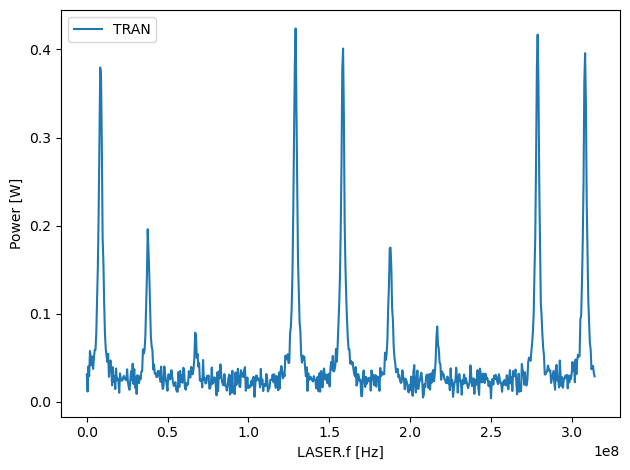

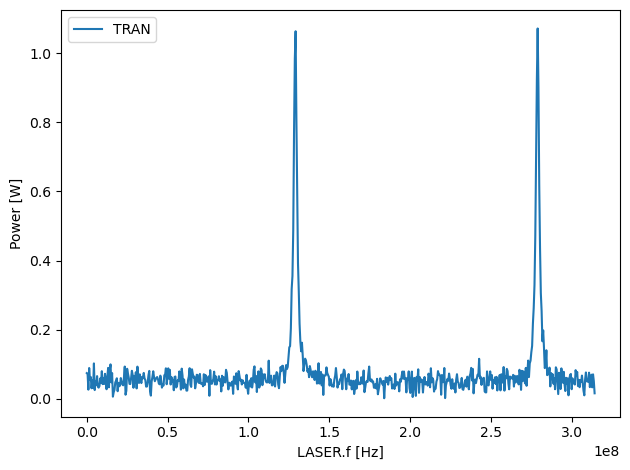

In [5]:
cav_align = CavityAlignment.two_mirror_cavity(
    Lcav = 1.0,          # Cavity length IC<-->OC
    Rc = (np.inf, 3.0),  # RoCs of IC and OC
    Refl = (0.95, 0.95), # Reflection off IC and OC
    Loss = (0.0, 0.0),   # Internal loss in IC and OC
    StSp = (1.0, 2.0)    # Distances SM1<-->SM2 and SM2<-->IC
)
cav_align.set_maxtem(11)

cav_align.add_misalignment_axes([cav_align.m.IC.xbeta], [-5e-4],  [5e-4])
cav_align.misalign_axes()

cav_align.cavity_scan(ppbw_resolution = 5, scan_range_in_fsrs=2.1, noisy=True, plot=True);

cav_align.sm2.xbeta = cav_align.m.IC.xbeta.value/2
cav_align.cavity_scan(ppbw_resolution = 5, scan_range_in_fsrs=2.1, noisy=True, plot=True);


In [6]:
type(cav_align.m.IC.xbeta)

finesse.parameter.Parameter

maxtem=1 calculation finished
maxtem=3 calculation finished
maxtem=7 calculation finished
maxtem=11 calculation finished
maxtem=15 calculation finished
maxtem=19 calculation finished


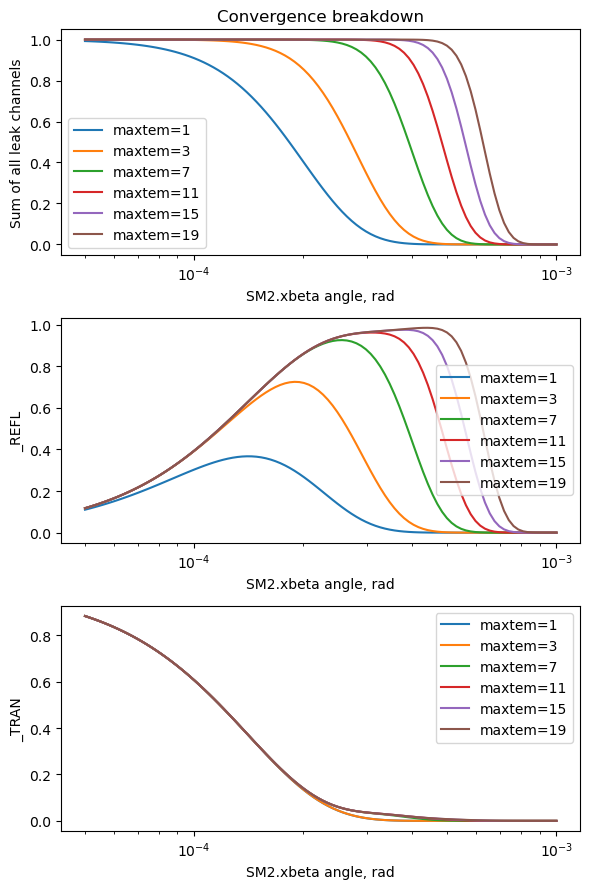

In [7]:
cav_align.m.IC.xbeta = 0
cav_align.sm2.xbeta = 0

cav_align.get_convergence_curves(axis = cav_align.sm2.xbeta,
                                 x = np.geomspace(5e-5,1e-3,100),
                                 maxtem_list = [1, 3, 7, 11, 15, 19],
                                 cavity_leak_channels = [cav_align.m.IC.p1.o, cav_align.m.OC.p2.o],
                                 leak_channel_names = ['_REFL', '_TRAN'],
                                 lock_to_mode=[0,0],
                                 plot = 'all',
                                 plot_logx = True
                                );

In [8]:
cav_align.init_all_steering_motors(pos_coef=1.2e-6, neg_coef=1.0e-6, uncertainty=0.1)

In [9]:
print(cav_align.dof_info(cav_align.sm2.xbeta))
cav_align.move_steering_motor(cav_align.sm2.xbeta, 100)
print(cav_align.dof_info(cav_align.sm2.xbeta))
cav_align.move_steering_motor(cav_align.sm2.xbeta, -100)
print(cav_align.dof_info(cav_align.sm2.xbeta))

SM2.xbeta = 0.0 radians, motor pos = 0
SM2.xbeta = 0.00011477262529358962 radians, motor pos = 100
SM2.xbeta = 1.3463964593456152e-06 radians, motor pos = 0


# Alignment data post-processing

In [10]:
# #
# #
# import finesse

# f_cav = finesse.Model()
# f_cav.parse("""
# l LASER P=1
# s SL LASER.p1 M3.p4
# bs M3 alpha=45 L=0 T=0.05
# s SM3M0 M3.p2 M0.p1 L=0.1
# bs M0 alpha=45 R=1 T=0
# s SM0M1 M0.p2 M1.p1 L=4.9
# bs M1 alpha=45 R=1 T=0 Rc=10.2
# s SM1M2 M1.p2 M2.p1 L=0.1
# bs M2 alpha=45 L=0 T=0.05 xbeta=0
# s SM2M3 M2.p2 M3.p1 L=4.9
# s sp M2.p4 MT.p1
# m MT R=1 T=0
# # pd REFL M3.p3.o
# pd TRAN M2.p3.o

# cav CAV M3.p2.o
# modes(maxtem=9)
# """)
# f_cav.beam_trace()

# out = f_cav.run("xaxis(M1.phi, lin, 0, 1000, 3000)")

# rng = np.random.default_rng()

# x = out.x[0]
# y = out['TRAN'] + np.abs( rng.normal(
#     loc = max(out['TRAN']) * 5e-2,
#     scale = max(out['TRAN']) * 2e-2,
#     size = len(out['TRAN'])
# ) )

cav_align = CavityAlignment.two_mirror_cavity(
    Lcav = 1.0,          # Cavity length IC<-->OC
    Rc = (np.inf, 3.0),  # RoCs of IC and OC
    Refl = (0.95, 0.95), # Reflection off IC and OC
    Loss = (0.0, 0.0),   # Internal loss in IC and OC
    StSp = (1.0, 2.0)    # Distances SM1<-->SM2 and SM2<-->IC
)
cav_align.set_maxtem(11)

cav_align.m.IC.xbeta = 3e-4
x, y = cav_align.cavity_scan(ppbw_resolution = 10, scan_range_in_fsrs=1.0, noisy=True)

In [11]:
import numpy as np
import scipy
import warnings

def part_autocorr(a, i_start=0, i_stop=None, norm_by_width=False):
    """This is not partial autocorrelation (PACF) but rather standard discrete autocorrelation function
    calculated at certain points (values of lag), which correspond to shift values between `i_start` and `i_stop`."""
    N = len(a)
    if i_stop is None:
        i_stop = N-1
    toeplitz_nrows = i_stop-i_start+1
    toeplitz_ncols = N - i_start
    
    # Creating an auxiliary vector padded with zeros on the left (using np.zeros() because it is faster than np.pad())
    a_aux = np.zeros(2*toeplitz_ncols - 1, dtype=a.dtype)
    a_aux[-toeplitz_ncols:] = a[:toeplitz_ncols]
    strides=a_aux.strides[0]
    # Creating a partial Toeplitz matrix using numpy's strides (fast but need to be very careful)
    a_toeplitz = np.lib.stride_tricks.as_strided(a_aux[toeplitz_ncols-1:], (toeplitz_nrows,toeplitz_ncols), (-strides,strides))
    # creating the complex conjugated vector for multiplication
    ac_v = np.conj(a[-toeplitz_ncols:])
    # Using the Einstein summation as it is faster than @
    res = np.einsum('ij,j->i', a_toeplitz, ac_v)
    # Normalisation by the width of the region with non-zero values
    if norm_by_width:
        res /= np.arange(toeplitz_ncols, toeplitz_ncols-toeplitz_nrows, -1)
    
    return res

def part_autocorr_scaled(xdata, ydata, start_x=None, end_x=None, norm_by_width=False):
    """
    Calculates the autocorrelation function for lag values between `start_x` and `end_x`.
    Returns the corresponding array of lags and the autocorrelation function values.
    If `norm_by_width`==True, then the result is divided by the amount of non-zero elements in the calculation.
    """
    if start_x is None:
        start_x = min(xdata)
    if end_x is None:
        end_x = max(xdata)
    minpos = np.argmin(np.abs(start_x-xdata))
    maxpos = np.argmin(np.abs(end_x-xdata))
    acf_x = xdata[minpos:maxpos+1]-xdata[0]
    acf = part_autocorr(ydata, i_start=minpos, i_stop=maxpos, norm_by_width=norm_by_width)
    return acf_x, acf

def find_FSR(xdata, ydata, minFSR=None, maxFSR=None, norm_by_width=False):
    """Looks for the FSR (periodicity) in `ydata` by selectively calculating the autocorrelation function
    between x values `minFSR` and `maxFSR` and locating the maximum.
    
    Returns the FSR value in the units of x.
    
    When working with continuous cavity scans, it is advisable to locate the FSR first using a wider range
    and then keep tracking it using a narrow range to speed up the calculations.
    
    If `norm_by_width`==True, then the result is divided by the amount of non-zero elements in the calculation.
    This can suppress small-lag peaks (e.g. the HOM separation) but exaggerate the peaks at multiple FSRs.
    Therefore, it should be used with maxFSR < 2*FSR where FSR is the actual FSR.

    TODO: possibly add checks if a peak at 1/2 frequency of the obtained one exists and scale to it if so.
    """
    acf_x, acf = part_autocorr_scaled(xdata, ydata, start_x=minFSR, end_x=maxFSR, norm_by_width=norm_by_width)
    return acf_x[np.argmax(acf)]

class CavityScanPreProcess():
    """
    Pre-processing the cavity scans"""
    def __init__(self,
                 params = {},
                 **kwargs
                ):
        """
        Parameters
        ----------
        params: Dictionary to update/add values to the internal parameter dictionary, `params`.
        Parameters can also be passed separately as kwargs, see below for the description of entries in this dict.
        **kwargs : 
            Other parameters to be update or stored in the internal parameter dictionary, `CavityScanPreProcess().params`.
            Note that any parameters specified as kwargs will take preference over those specified in the `params` argument.
            Parameter names and meaning as follows:
        FSRs_per_scan_upper_limit, FSRs_per_scan_lower_limit: float
            Upper/lower limit for the number of FSRs per scan that the measured FSRs are guaranteed to exceed never.
        FSR_track_range : float
            The range around the previous FSR to use for keeping track of the FSR, in the units of one FSR.
        median_filter_size_FWHM_multiplier : float
            Number of FWHMs to use as the size parameter for the median filter used to obtain the noise baseline. Default is 3.0
        median_filter_max_window_in_FSRs : float
            Max size for the median filter window in the units of one FSR.
        peak_width_upper_limit_in_FSRs : float
            The upper limit on the width of cavity peaks (for all detectable modes) in the units of one FSR. Defaiult is 0.1
        peak_height_above_noise_threshold_in_sigmas : float
            The preprocessing script will calculate the noise baseline and the standard deviation (sigma) of noise from this baseline.
            This parameter regulates the minimum height of the cavity peaks above the noise baseline in the units of sigma.
            Default is 3.0 (three sigma deviation)
        minimum_peak_width_in_data_points : int
            Minimum width of the detected peaks in the units of data points. Default is 10. 
            The resolution of scans should be selected appropriately. A warning will be given if the expected FWHM is smaller
            than this parameter.
        peak_width_lower_limit_in_FWHMs : float
            When tracking the peaks, this value sets the minimum width for the peaks
            in the units of FWHM of the highest peak during the last scan. Default is 0.5.
        """
        self.last_FSR = None
        self.last_FWHM = None

        self.params = {
            'FSRs_per_scan_upper_limit' : 5.0,
            'FSRs_per_scan_lower_limit' : 1.1,
            'FSR_track_range' : 0.4,
            'peak_width_upper_limit_in_FSRs' : 0.1,
            'median_filter_size_FWHM_multiplier' : 20,
            'median_filter_max_window_in_FSRs' : 0.2,
            'peak_height_above_noise_threshold_in_sigmas' : 3.0,
            'minimum_peak_width_in_data_points' : 4,
            'peak_width_lower_limit_in_FWHMs' : 0.5
        }
        self.params.update(params)
        self.params.update(kwargs)

    # TODO:
    # 1. Apply the roll so that the array starts at the largest peak before calling find_peaks -- DONE
    # 2. (can be added later) If averaging the scan, average the data at this point to smoothen the noise out -- DONE
    # 3. Concatenate the data with part of itself (peak_width_upper_limit_in_FSRs portion) -- DONE
    # 4. Find the peaks -- DONE
    # 5. Get rid of any extra peaks in the result (We are only concerned by the one that is at the beginning) -- DONE

    # TODO:
    # Add bypassing of some pre-processing steps when using the simulation to speed-up the training. -- DONE

    # TODO:
    # Potentially add a moving average filter before applying the roll to center more precisely at the highest peak.

    # TODO:
    # Identify the mode with the lowest loss in the final state to use as the utlimate reward in the simulation training
    # (penalise if a cavity has been aligned to the wrong mode)

    # TODO:
    # potentially this can be extended to align the cavity to a higher-order mode instead.
    def process_cavity_scan(self,
                            xdata : float | np.ndarray,
                            ydata : float | np.ndarray,
                            bypass_FSR_preprocessing : bool = False,
                            plot : bool = False
                           ) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, float]:
        """
        Preprocessing the cavity scan given by `xdata` and `ydata`.
        
        Parameters
        ----------
        xdata, ydata : numpy.ndarray or list of numpy.nd_array
            If 1D arrays, a single scan is assumed.
            If list of 1D arrays, each entry in the list is a separate scan. The results will be averaged.
            The data must be organised such that `xdata` values are in the ascending order.
            `xdata` values must be evenly spread.
        bypass_FSR_preprocessing : bool
            If `True`, it is assumed that the provided cavity scans already cover exactly one FSR each.
            This skips the FSR estimation which should give a speed-up when training using simulated data.
        plot : bool
            If `True`, the processed data is plotted.

        Returns
        -------
        peak_positions : numpy.ndarray
            Positions of the peaks within the FSR (range normalised to [0,1])
            The highest peak should be at 0.
        peak_dominances : numpy.ndarray
            "Dominances" of the peaks (integrals of the peaks within FWHMs divided by the integral of the whole FSR scan y1).
            Range within [0,1].
        peak_heights : numpy.ndarray
            The heights of the peaks, normalised to the highest peak (range within [0,1])
        peak_FWHMs : numpy.ndarray
            Widths of the peaks in the units of one FSR (range within [0,1])
        x1 : numpy.ndarray
            x data of the processed scan, normalised to one FSR (range within [0,1])
        y1 : numpy.ndarray
            y data of the processed scan, normalised to the highest peak (range within [0,1])
        FSR : float
            The FSR in the units of the original x axis (provided for scaling other outputs back to the scan units).
        
        """
        if isinstance(xdata, np.ndarray) and isinstance(ydata, np.ndarray):
            _xdata = [xdata]
            _ydata = [ydata]
        elif isinstance(xdata, list) and isinstance(ydata, list):
            _xdata = xdata
            _ydata = ydata
        else:
            raise TypeError("Both xdata and ydata must be either 1D numpy arrays or lists of 1D numpy arrays.")

        last_FSR = self.last_FSR

        # If we have multiple scans, we detect the FSR in each one,
        # leave only the central part of the scan corresponding to one FSR,
        # scale the up or down aby interpolating and resampling if the number of points is different.
        # rearrange the data at each one to start at the highest peak
        # And take the average (also need to scale in case)
        new_FSR_list = []
        # When avaraging, Npoints will be the number of points used to resample the data
        # Currently the number of points in one FSR in the first scan is used
        Npoints = 0
        y1_list = []

        for x, y in zip(_xdata, _ydata):
            x_span = x[-1] - x[0]
            x_step =  x[1] - x[0]

            if bypass_FSR_preprocessing:
                # Assuming that the scans already span exactly over one FSR
                new_FSR_list.append(x_span+x_step)
                y1 = y
            else:
                # Finding the FSR
                if last_FSR is None:
                    #This is the first run
                    this_FSR = find_FSR(x, y, 
                                        minFSR=1/self.params['FSRs_per_scan_upper_limit']*x_span,
                                        maxFSR=1/self.params['FSRs_per_scan_lower_limit']*x_span,
                                        norm_by_width=False) 
                else:
                    # We have a previous FSR estimation, will only be looking around it
                    maxFSR = last_FSR*(1+self.params['FSR_track_range']/2)
                    maxFSR = maxFSR if maxFSR < 1/self.params['FSRs_per_scan_lower_limit']*x_span else \
                    1/self.params['FSRs_per_scan_lower_limit']*x_span
                    minFSR = last_FSR*(1-self.params['FSR_track_range']/2)
                    minFSR = minFSR if minFSR > 1/self.params['FSRs_per_scan_upper_limit']*x_span else \
                    1/self.params['FSRs_per_scan_upper_limit']*x_span
                    this_FSR = find_FSR(x, y,
                                        minFSR=minFSR,
                                        maxFSR=maxFSR,
                                        norm_by_width = (x_span < 2*last_FSR)
                                       )
                new_FSR_list.append(this_FSR)
                # TODO: identify and process the cases when the tracking fails 
                # (e.g. skip the scan if the FSR is very different fropm the previous values)
    
                # Slicing the data: taking one FSR in the middle of the x range
                left_pos = int(len(x)/2 - this_FSR/2/x_step)
                right_pos = int(len(x)/2 + this_FSR/2/x_step)
                # x1 = x[left_pos:right_pos] # We actually don't need this array
                y1 = y[left_pos:right_pos]

            # Finding the highest peak and rolling the array to start at it
            maxpos = np.argmax(y1)
            y1 = np.roll(y1, -maxpos)

            # Normalising the array
            y1 = y1/y1[0]

            if Npoints == 0:
                # This is the first scan, storing its number of points
                Npoints = len(y1)
                # Normalising the x range so that (0...1) is one FSR (x_i = i/Npoints, i=0...Npoints-1)
                x_range = np.arange(Npoints) / Npoints
            else:
                # Resampling the data to the first scan if the number of points does not match
                Npoints2 = len(y1)
                if Npoints2 != Npoints:
                    y1 = np.interp(x_range, np.arange(Npoints2)/Npoints2, y1)

            # Appending the y1 array to the list
            y1_list.append(y1)

        # Now we have a normalised x_range and a list of y-value of scans
        # where each scan should start at the highest peak and span over one FSR
        # Now we can average these scans
        y1 = np.mean(np.stack(y1_list), axis=0)
        new_FSR = sum(new_FSR_list)/len(new_FSR_list)
        x1 = x_range # normalised so that FSR = 1

        # TODO: this is where we can identify problems with some of the scans
        # such as centring on the wrong peak (likely if two peaks have similar height)
        # E.g. we can calculate the correlation between y1 and each of the arrays in y1_list,
        # and if there are outlier arrays with low correlation, throw them out and recalculate y1
        # This will likely be a huge processing bottleneck when using the simulated data,
        # so it should only be applied to the real data after the sim-to-real transition

        # Obtaining the noise baseline
        if self.last_FWHM is None:
            expected_FWHM_size = int(self.params['peak_width_upper_limit_in_FSRs'] * len(x1))
        else:
            expected_FWHM_size = int( self.last_FWHM/self.last_FSR * len(x1) )
        
        noise_baseline_size = int(expected_FWHM_size * self.params['median_filter_size_FWHM_multiplier'])
        if noise_baseline_size > self.params['median_filter_max_window_in_FSRs']*len(x1):
            noise_baseline_size = int( self.params['median_filter_max_window_in_FSRs']*len(x1) )
            
        noise_baseline = scipy.ndimage.median_filter(y1, size=noise_baseline_size)

        # Figuring out the height threshold above the baseline
        # Step 1: subtracting the baseline
        diff = y1-noise_baseline
        # Step 2: removing the 3-sigma outliers, e.g. the peaks
        sigma0 = diff.std()
        diff1 = diff[np.abs(diff)<3*sigma0]
        # Step 3: recalculating sigma
        sigma1 = diff1.std()
        # Step 4: calculating the height threshold
        peak_height_low = noise_baseline+self.params['peak_height_above_noise_threshold_in_sigmas']*sigma1

        # Setting the low limit for the peaks' width
        if self.last_FWHM is not None:
            if (expected_FWHM_size*self.params['peak_width_lower_limit_in_FWHMs'] < self.params['minimum_peak_width_in_data_points']):
                warnings.warn(f"""
                Expected FWHM ({int(expected_FWHM_size)} pts, {self.last_FWHM} Hz) is too narrow.
                Use with caution.
                Increase of resolution is advised if possible.
                """)
                peak_width_low = int(expected_FWHM_size*self.params['peak_width_lower_limit_in_FWHMs'])
            else:
                peak_width_low = self.params['minimum_peak_width_in_data_points']
        else:
            peak_width_low = self.params['minimum_peak_width_in_data_points']

        # Concatenating the y array with a small portion of itself to ensure the highest peak is handled correctly
        Npoints_add = int(self.params['peak_width_upper_limit_in_FSRs']*len(y1))
        y1c = np.concatenate((y1[-Npoints_add:], y1))
        peak_height_low_c = np.concatenate((peak_height_low[-Npoints_add:], peak_height_low))
                          
        # Finding the peaks
        peaks,props = scipy.signal.find_peaks(
            y1c,
            height = peak_height_low_c,
            width = peak_width_low
        )

        # Deleting any extra peaks found in the concatenated part on the left
        delete_pos = np.where(peaks < Npoints_add)
        peaks = np.delete(peaks, delete_pos)
        for k, v in props.items():
            props[k] = np.delete(v, delete_pos)
        
        Npeaks = len(peaks)

        # Calculating the peak dominances (integrals over FWHMs of each peak) divided by the inegral over the whole FSR (sum of y1)
        sum_y1 = y1.sum()
        peak_dominances=np.zeros(Npeaks)
        for k in range(Npeaks):
            peak_dominances[k] = y1c[int(props['left_ips'][k]):int(props['right_ips'][k])+1].sum() / sum_y1

        # Converting the peak positions and other properties back to correspond to array y1
        peaks = peaks - Npoints_add
        for k, v in props.items():
            # The following entries have the meaning of positions and need to be converted back to y1
            if k in ['left_ips', 'right_ips', 'left_bases', 'right_bases', 'left_edges', 'right_edges']:
                props[k] = v - Npoints_add

        # TODO: We should have a peak at y1[0] now. If we do not, then something's wrong.
        # Might be worth adding a check and a warning or drop the processing if this happened
        
        # We want to return the peaks sorted by height
        sort_p = props['peak_heights'].argsort()[::-1]
        props = {k: v[sort_p] for k, v in props.items()}
        peaks = peaks[sort_p]

        # Peak positions in fractions of the FSR
        peak_positions = peaks/len(y1)

        # Peak FWHMs in fractions of the FSR
        peak_FWHMs = props['widths']/len(y1)

        # Calculating the new FWHM of the main peak in Hz
        if Npeaks>0:
            new_FWHM = props['widths'][0]*new_FSR/len(y1)
        else:
            new_FWHM = np.nan

        if plot:
            plt.figure()
            plt.plot(x1,y1)
            plt.plot(x1,noise_baseline, ls="--")
            plt.plot(x1,noise_baseline+self.params['peak_height_above_noise_threshold_in_sigmas']*sigma1, ls=":")
            for peak in peaks:
                plt.axvline(x1[peak], ls="--")
            plt.xlabel('Scan variable (units of FSR)')
            plt.ylabel('Normalised cavity scan')
            plt.show()

        # Updating the values used for tracking
        self.last_FSR = new_FSR if new_FSR == new_FSR else None
        self.last_FWHM = new_FWHM if new_FWHM == new_FWHM else None

        return peak_positions, peak_dominances, props['peak_heights'], peak_FWHMs, x1, y1, new_FSR
           

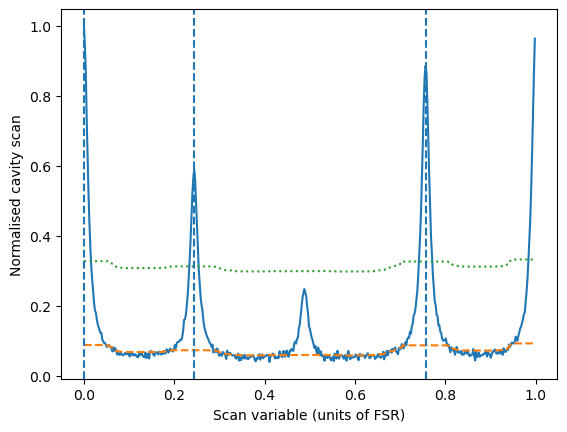

[0.13263541 0.07870516 0.12614153]


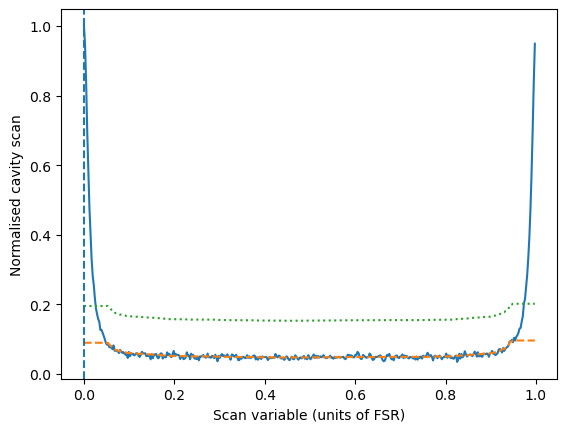

[0.22888379]


In [12]:
cav_align = CavityAlignment.two_mirror_cavity(
    Lcav = 1.0,          # Cavity length IC<-->OC
    Rc = (np.inf, 3.0),  # RoCs of IC and OC
    Refl = (0.95, 0.95), # Reflection off IC and OC
    Loss = (0.0, 0.0),   # Internal loss in IC and OC
    StSp = (1.0, 2.0)    # Distances SM1<-->SM2 and SM2<-->IC
)
cav_align.set_maxtem(11)

cav_align.m.IC.xbeta = 3e-4

Nave=10
xlist = [] 
ylist = []
for i in range(Nave):
    x, y = cav_align.cavity_scan(ppbw_resolution = 10, scan_range_in_fsrs=2.1, noisy=True)
    xlist.append(x)
    ylist.append(y)


cav_pp = CavityScanPreProcess()
_, dom, _, _, _, _, _ = cav_pp.process_cavity_scan(xlist,ylist, plot=True)#, bypass_FSR_preprocessing=True)
print(dom)

cav_align.sm2.xbeta = 1.5e-4

xlist = [] 
ylist = []
for i in range(Nave):
    x, y = cav_align.cavity_scan(ppbw_resolution = 10, scan_range_in_fsrs=2.1, noisy=True)
    xlist.append(x)
    ylist.append(y)
_, dom, _, _, _, _, _ = cav_pp.process_cavity_scan(xlist,ylist, plot=True)#, bypass_FSR_preprocessing=True)
print(dom)


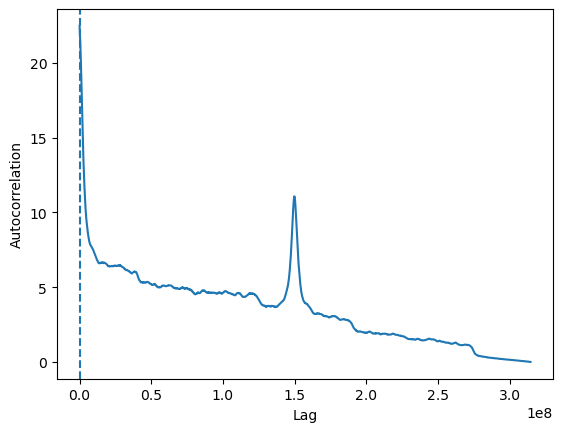

In [13]:
acf_x, acf = part_autocorr_scaled(x, y, start_x=20, end_x=None, norm_by_width=False)
plt.plot(acf_x, acf)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.axvline(find_FSR(x, y, minFSR=200, maxFSR=300), ls="--")
plt.show()

In [14]:
%timeit find_FSR(x, y, minFSR=20)

793 μs ± 14.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [15]:
%timeit find_FSR(x, y, minFSR=200, maxFSR=300)

13.2 μs ± 132 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [16]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class CavityAlignmentEnv(gym.Env):
    def __init__(self,
                 cav_sim : CavityAlignment,
                 scan_preprocess : CavityScanPreProcess,
                 Npeaks = 10,
                ):
        # super(CavityAlignmentEnv, self).__init__() # Probably not needed?

        self.Npeaks = Npeaks
        # Continuous action space: 4 motor inputs (pitch and yaw for two mirrors)
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(4,), dtype=np.float32)

        # Observation space
        self.observation_space = spaces.Dict({
            "peak_dominances": spaces.Box(low=0.0, high=1.0, shape=(Npeaks,), dtype=np.float32),
            "peak_positions" : spaces.Box(low=0.0, high=1.0, shape=(Npeaks,), dtype=np.float32),
            "peak_FWHMs" : spaces.Box(low=0.0, high=1.0, shape=(Npeaks,), dtype=np.float32),
        })

        # Simulation model of the cavity
        self.cav_sim = cav_sim

        # An object used for pre-processing cavity scans
        self.scan_preprocess = scan_preprocess

        # Number of steps without improvement before cutoff
        self._MAX_NO_IMPROVEMENT = 20
        # Number of steps without seeing any peaks before giving up
        self._MAX_NO_PEAKS = 20
        # Maximum allowed step count for one motor operation (assuming the same one on each motor)
        self._MAX_COUNTS_PER_STEP=100

    def _get_obs_and_info(self):
        # Taking a cavity scan
        self._x, self._y = self.cav_sim.cavity_scan(ppbw_resolution=10, scan_range_in_fsrs=1.0)
        # Preprocessing the scan
        self._peak_positions, self._peak_dominances, self._peak_heights, self._peak_FWHMs, self._x1, self._y1, self._FSR = \
        self.scan_preprocess.process_cavity_scan(self._x, self._y, bypass_FSR_preprocessing=True)
        # Number of peaks returned by the preprocessing script
        Npeaks_found = len(self._peak_positions)
        # If Npeaks_found is less than Npeaks (in observation space), fill the missing parameters with zeros
        # If Npeaks_found is greater than Npeaks, ignore the smallest peaks
        # Returned peaks are sorted by peak height

        # Filling in the observation space with zeros
        obs = {
            "peak_dominances" : np.zeros(self.Npeaks, dtype=float),
            "peak_positions"  : np.zeros(self.Npeaks, dtype=float),
            "peak_FWHMs"      : np.zeros(self.Npeaks, dtype=float)
        }
        # Number of peaks to copy
        Ncopy = Npeaks_found if  Npeaks_found < self.Npeaks else self.Npeaks
        # Copying the peaks into the observation space
        obs["peak_dominances"][:Ncopy] = self._peak_dominances[:Ncopy]
        obs["peak_positions"][:Ncopy]  = self._peak_positions[:Ncopy]
        obs["peak_FWHMs"][:Ncopy]  = self._peak_FWHMs[:Ncopy]

        # info dict
        info = {
            "x1" : self._x1,
            "y1" : self._y1,
            "FSR" : self._FSR,
            "Npeaks_found" : Npeaks_found
        }
        return obs, info
        

    def reset(self, seed=None):
        # Seeding the RNG
        super().reset(seed=seed)

        # Providing the RNG to the simulation
        self.cav_sim.connect_numpy_rng(self.np_random)
        
        # Resetting counters
        self._best_dominance = 0
        self._no_improvement_steps = 0
        self._no_peak_steps = 0

        # Misaligning some of the cavity mirrors
        self.cav_sim.misalign_axes()

        # Resetting the steering mirrors and their motors to all zeroes
        self.cav_sim.set_steering_angles()
        self.cav_sim.reset_steering_motors()

        # Taking a cavity scan
        observation, info = self._get_obs_and_info()

        return observation, info

    def step(self, action):
        # Creating a dictionary with motor steps in counts
        counts_dict = {}
        for i,k in enumerate(self.cav_sim.steering_motors.keys()):
            counts_dict[k] = int(action[i] * self._MAX_COUNTS_PER_STEP)

        # Moving the mirrors
        # TODO: implement the case for the sim-to-real transition here
        self.cav_sim.move_steering_motors(counts_dict)

        # Take a cavity scan
        observation, info = self._get_obs_and_info()
        
        # counting consecutive steps with no peaks
        if info["Npeaks_found"] == 0:
            self._no_peak_steps += 1
        else:
            self._no_peak_steps = 0

        # counting consecutive steps with no improvement
        # TODO: possibly track the moving average instead
        # or forget the best peak ratio with time to allow the exporation of the parameter space
        if info["Npeaks_found"] == 1:
            if observation["peak_dominances"][0] > self._best_dominance:
                self._best_dominance = observation["peak_dominances"][0]
                self._no_improvement_steps = 0
            else:
                self._no_improvement_steps += 1
        else:
            self._no_improvement_steps = 0

        truncated = self._no_peak_steps >= self._MAX_NO_PEAKS
        terminated = self._no_improvement_steps >= self._MAX_NO_IMPROVEMENT

        # Define reward function (example: maximize single peak height and minimize multiple peaks)
        if info["Npeaks_found"] == 0:
            # No peaks -> no reward!
            reward = 0
        else:
            reward = observation["peak_dominances"][0]**2
            reward /= info["Npeaks_found"] 

        if terminated:
            reward *= 2
        if truncated:
            reward = 0
        # reward = self.state["peak_ratio"] - 0.1 * abs(self.state["num_peaks"] - 1)

        return observation, reward, terminated, truncated, info

    def render(self):
        pass

    def close(self):
        pass


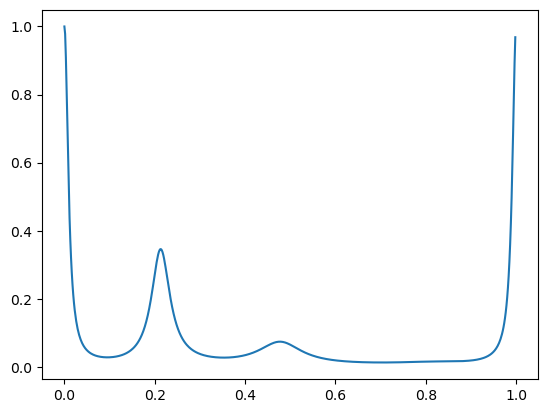

In [17]:
from stable_baselines3 import SAC

cav_align = CavityAlignment.two_mirror_cavity(
    Lcav = 1.0,          # Cavity length IC<-->OC
    Rc = (np.inf, 3.0),  # RoCs of IC and OC
    Refl = (0.95, 0.95), # Reflection off IC and OC
    Loss = (0.0, 0.0),   # Internal loss in IC and OC
    StSp = (1.0, 2.0)    # Distances SM1<-->SM2 and SM2<-->IC
)
cav_align.set_maxtem(5)

cav_align.add_misalignment_axes([
    cav_align.m.IC.xbeta,
    cav_align.m.IC.ybeta,
    cav_align.m.OC.xbeta,
    cav_align.m.OC.ybeta,
], [-2e-4]*4, [2e-4]*4)

cav_align.init_all_steering_motors(pos_coef=1.2e-7, neg_coef=1.0e-7, uncertainty=0.1)

cav_pp = CavityScanPreProcess()


env = CavityAlignmentEnv(cav_align, cav_pp)

env.reset();
_,_,_,_,info = env.step([0,0,0,0])

plt.plot(info['x1'],info['y1'])
plt.show()
# model = SAC("MultiInputPolicy", env, verbose=1)
# model.learn(total_timesteps=10000)

In [19]:
from stable_baselines3.common.vec_env import SubprocVecEnv

def make_env():
    """Returns a function that creates a new instance of the environment."""
    def _init():
        cav_align = CavityAlignment.two_mirror_cavity(
            Lcav = 1.0,          # Cavity length IC<-->OC
            Rc = (np.inf, 3.0),  # RoCs of IC and OC
            Refl = (0.95, 0.95), # Reflection off IC and OC
            Loss = (0.0, 0.0),   # Internal loss in IC and OC
            StSp = (1.0, 2.0)    # Distances SM1<-->SM2 and SM2<-->IC
        )
        cav_align.set_maxtem(5)
        
        cav_align.add_misalignment_axes([
            cav_align.m.IC.xbeta,
            cav_align.m.IC.ybeta,
            cav_align.m.OC.xbeta,
            cav_align.m.OC.ybeta,
        ], [-2e-4]*4, [2e-4]*4)
        
        cav_align.init_all_steering_motors(pos_coef=1.2e-7, neg_coef=1.0e-7, uncertainty=0.1)
        
        cav_pp = CavityScanPreProcess()
        env = CavityAlignmentEnv(cav_align, cav_pp)
        return env
    return _init


import matplotlib.pyplot as plt
from stable_baselines3.common.callbacks import BaseCallback

class PlottingCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.actor_losses = []
        self.critic_losses = []
        self.entropy_coefficients = []
        self.episode_rewards = []

        # Create the figure and axes once, outside the callback
        self.fig, self.axs = plt.subplots(2, 2, figsize=(12, 8))
        plt.ion()  # Turn on interactive mode

    def _on_step(self) -> bool:
        # Track the loss values and rewards at each training step
        if self.n_calls % self.model.n_envs == 0:  # At the end of each episode
            # Record the actor loss, critic loss, and entropy coefficient
            actor_loss = self.model.actor.loss.item() if hasattr(self.model.actor, 'loss') else 0
            critic_loss = self.model.critic.loss.item() if hasattr(self.model.critic, 'loss') else 0
            
            # Check if ent_coef is a string or a numeric value
            if isinstance(self.model.ent_coef, str):  # If it's a string (like 'auto')
                ent_coef = 0  # You can handle this case based on your needs (e.g., skip or set to 0)
            else:
                ent_coef = self.model.ent_coef.item() if hasattr(self.model.ent_coef, 'item') else 0

            self.actor_losses.append(actor_loss)
            self.critic_losses.append(critic_loss)
            self.entropy_coefficients.append(ent_coef)

            # Record the final reward of the episode
            final_rewards = [info.get('episode', {}).get('r', 0) for info in self.locals['infos']]
            for reward in final_rewards:
                self.episode_rewards.append(reward)

        # Update the plots in the same figure
        self.axs[0, 0].cla()  # Clear the axes for actor and critic loss
        self.axs[0, 1].cla()  # Clear the axes for entropy coefficient
        self.axs[1, 0].cla()  # Clear the axes for episode rewards
        self.axs[1, 1].cla()  # Clear the empty axis (can be omitted if not used)

        # Plot actor and critic loss
        self.axs[0, 0].plot(self.actor_losses, label='Actor Loss', color='blue')
        self.axs[0, 0].plot(self.critic_losses, label='Critic Loss', color='orange')
        self.axs[0, 0].set_xlabel('Steps')
        self.axs[0, 0].set_ylabel('Loss')
        self.axs[0, 0].set_title('Actor and Critic Loss')
        self.axs[0, 0].legend()

        # Plot entropy coefficient
        self.axs[0, 1].plot(self.entropy_coefficients, label='Entropy Coefficient', color='green')
        self.axs[0, 1].set_xlabel('Steps')
        self.axs[0, 1].set_ylabel('Entropy Coefficient')
        self.axs[0, 1].set_title('Entropy Coefficient')
        self.axs[0, 1].legend()

        # Plot episode rewards
        self.axs[1, 0].plot(self.episode_rewards, label='Episode Reward', color='red')
        self.axs[1, 0].set_xlabel('Episode')
        self.axs[1, 0].set_ylabel('Reward')
        self.axs[1, 0].set_title('Episode Reward')
        self.axs[1, 0].legend()

        # Tight layout for the plots
        self.fig.tight_layout()

        # Redraw the figure and update it on the screen without opening a new window
        plt.draw()  # Updates the existing figure
        plt.pause(0.001)  # Allow the figure to update

        return True


%matplotlib qt

num_envs = 10  # Adjust based on CPU cores
envs = SubprocVecEnv([make_env() for _ in range(num_envs)])

model = SAC("MultiInputPolicy", envs, verbose=1, device="cpu")
# envs = SubprocVecEnv([make_env() for _ in range(1)])
# model = SAC("MultiInputPolicy", env, verbose=1, device="cpu")
plotting_callback = PlottingCallback()
model.learn(total_timesteps=100000, log_interval=100, callback=plotting_callback)

Using cpu device


/var/folders/71/hpfrbnmn65l6vwmlz9wh737c0000gs/T/ipykernel_923/2904663145.py:302: UserWarning: 
                Expected FWHM (7 pts, 1911398.0049378849 Hz) is too narrow.
                Use with caution.
                Increase of resolution is advised if possible.
                
Process ForkServerProcess-19:
Process ForkServerProcess-17:
Process ForkServerProcess-20:
Process ForkServerProcess-12:
Process ForkServerProcess-13:
Process ForkServerProcess-16:
Process ForkServerProcess-11:
Process ForkServerProcess-14:
Process ForkServerProcess-15:
Process ForkServerProcess-18:

KeyboardInterrupt



In [19]:
obs, info = env.reset()
terminated=False
while not terminated:
    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    print(reward)
    if truncated:
        print("truncated")
        break
    if terminated:
        print("terminated")

5041341.497490599 149896228.99999997 612
NPeaks: 2
2456585.4241312346 149896228.99999997 612
NPeaks: 2
0.06806289768834155
2456625.394984093 149896228.99999997 612
NPeaks: 2
0.06344923410955879
2456711.154715316 149896228.99999997 612
NPeaks: 2
0.07455122344282807
2456511.939334177 149896228.99999997 612
NPeaks: 2
0.06929144265620049
2456601.541581062 149896228.99999997 612
NPeaks: 2
0.07098489811798532
2456570.730234321 149896228.99999997 612
NPeaks: 2
0.06412872281279444
2456696.875490515 149896228.99999997 612
NPeaks: 2
0.05862887655277111
2456803.3698178194 149896228.99999997 612
NPeaks: 2
0.06774218932765774
2456628.2191951005 149896228.99999997 612
NPeaks: 2
0.06157098079066602
2456742.9750549295 149896228.99999997 612
NPeaks: 2
0.06048512245991795
2456762.2153262906 149896228.99999997 612
NPeaks: 2
0.0515654417096084
2456943.8163230107 149896228.99999997 612
NPeaks: 2
0.05360057225432143
2456898.6825627163 149896228.99999997 612
NPeaks: 2
0.047524278587259494
2457029.2976285922 

In [ ]:
def get_positive_frequencies(A):
    N=len(A)
    if len(A)//2==0:
        N2=int(N/2)
    else:
        N2=int((N+1)/2)
    return A[1:N2]

def get_frequency_array(t):
    N = len(t)
    timestep = np.diff(t)[0]
    f = np.fft.fftfreq(N, d=timestep)
    return f

## Class hierarchy

| Class name | Group | Functionality | Dependants | Objects used in |
|------------|-------|---------------|------------|-----------------|
|`MirrorImage` | Simulation | Drawing beam spots on mirrors | `MirrorAt45` | - |
|`MirrorAt45` | Simulation | Mirror description for the geometric model | - | `RectangularCavity` |
|`finesse.Model` | Simulation | (External) Finesse cavity model for scans | - | - |
|`RectangularCavity` | Simulation | Cavity description, interaction methods | - | - |